# Análise de Estabilidade de Talude com Nível d'Água — Método de Bishop Simplificado

Este notebook é uma extensão de `analise_estabilidade_talude_bishop.ipynb`. Ele realiza a mesma análise por **equilíbrio limite** (Bishop Simplificado, superfícies de ruptura **circulares**), agora considerando um **nível d'água (linha freática)** abaixo da superfície do terreno.

**O usuário informa:**
- As coordenadas (x, y) da linha superficial (perfil) do talude;
- As coordenadas (x, y) do **nível d'água** (linha freática), abaixo do terreno;
- As propriedades do solo: peso específico natural (γ, acima do N.A.), peso específico saturado (γ_sat, abaixo do N.A.), coesão efetiva (c') e ângulo de atrito efetivo (φ'), além do peso específico da água (γ_w).

**O que o notebook calcula:**
- O peso de cada fatia considerando a parcela **não saturada** (γ) e a parcela **saturada** (γ_sat);
- A **poropressão** na base de cada fatia, u = γ_w · h_w (h_w = altura do N.A. acima da base da fatia — condição hidrostática);
- A busca pelo **círculo crítico** (menor FS) e o **FS crítico** em termos de tensões efetivas;
- Uma comparação com o caso **sem nível d'água** (talude seco).

> **Simplificações assumidas:** solo homogêneo, superfície de ruptura circular, poropressão hidrostática medida na vertical a partir da linha freática (abordagem usual de programas de equilíbrio limite; despreza a curvatura das equipotenciais), poropressão nula acima do N.A. (sem sucção).

## 1. Importação de bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, minimize

%matplotlib inline

## 2. Dados de entrada — Geometria do talude

Informe as coordenadas **(x, y)** da linha superficial do talude, da esquerda para a direita (x crescente), em metros.

Exemplo abaixo: um talude simples com crista em x=0 e pé do talude em x=20 (altura de 10 m, inclinação 2H:1V), com trechos horizontais antes e depois para dar espaço à busca do círculo crítico.

In [2]:
# --- COORDENADAS DA LINHA SUPERFICIAL DO TALUDE (x, y) em metros ---
# Edite esta lista com os pontos do seu perfil, em ordem crescente de x.
superficie = [
    (-15.0, 10.0),   # início do platô superior (crista)
    (  0.0, 10.0),   # crista do talude
    ( 20.0,  0.0),   # pé do talude (inclinação 2H:1V)
    ( 40.0,  0.0),   # trecho horizontal inferior
]

surf_x = np.array([p[0] for p in superficie], dtype=float)
surf_y = np.array([p[1] for p in superficie], dtype=float)

assert np.all(np.diff(surf_x) > 0), "As coordenadas devem ter x estritamente crescente."

## 3. Dados de entrada — Nível d'água (linha freática)

Informe as coordenadas **(x, y)** do nível d'água, da esquerda para a direita (x crescente), em metros. O N.A. deve estar **abaixo (ou no máximo coincidente com)** a superfície do terreno — abaixo dele o solo é considerado **saturado**.

- Fora do intervalo informado, o N.A. é estendido horizontalmente (mesma cota do primeiro/último ponto);
- Por segurança, se algum trecho do N.A. ficar acima do terreno, ele é limitado à cota do terreno (o código avisa).

Exemplo: N.A. a 2 m de profundidade na crista, descendo pelo maciço e aflorando 0,5 m abaixo do terreno no pé do talude.

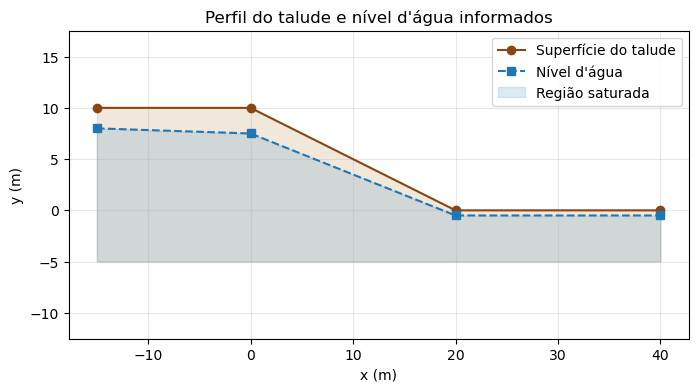

In [3]:
# --- COORDENADAS DO NIVEL D'AGUA (x, y) em metros ---
nivel_agua = [
    (-15.0,  8.0),
    (  0.0,  7.5),
    ( 20.0, -0.5),
    ( 40.0, -0.5),
]

wt_x = np.array([p[0] for p in nivel_agua], dtype=float)
wt_y = np.array([p[1] for p in nivel_agua], dtype=float)
assert np.all(np.diff(wt_x) > 0), "As coordenadas do N.A. devem ter x estritamente crescente."

# verificacao: N.A. abaixo do terreno
_xs_chk = np.linspace(min(surf_x[0], wt_x[0]), max(surf_x[-1], wt_x[-1]), 1000)
if np.any(np.interp(_xs_chk, wt_x, wt_y) > np.interp(_xs_chk, surf_x, surf_y) + 1e-9):
    print("AVISO: o N.A. informado fica acima do terreno em algum trecho; "
          "nesses pontos ele sera limitado a cota do terreno.")

plt.figure(figsize=(8, 4))
plt.plot(surf_x, surf_y, "o-", color="saddlebrown", label="Superfície do talude")
plt.fill_between(surf_x, surf_y, surf_y.min() - 5, color="tan", alpha=0.3)
plt.plot(wt_x, wt_y, "s--", color="tab:blue", label="Nível d'água")
plt.fill_between(surf_x, np.minimum(np.interp(surf_x, wt_x, wt_y), surf_y),
                 surf_y.min() - 5, color="tab:blue", alpha=0.15, label="Região saturada")
plt.title("Perfil do talude e nível d'água informados")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.axis("equal")
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

### 3.1 Identificação automática da crista e do pé do talude

O código localiza automaticamente a **crista** (ponto mais alto) e o **pé** (ponto mais baixo logo após a crista) do talude a partir das coordenadas informadas. Essa informação é usada apenas para **dimensionar automaticamente a região de busca** do círculo crítico (Seção 6) — ela não limita a forma da superfície de ruptura em si.

> Válido para um talude "simples", com um único trecho descendente entre um platô superior e um platô inferior (como no exemplo). Para geometrias mais complexas (múltiplas bermas, ondulações), ajuste manualmente `x_crest`, `x_toe` e/ou os intervalos de busca da Seção 6.

In [4]:
# indice do ultimo ponto na maior elevacao (crista) e do primeiro ponto na
# menor elevacao encontrado a partir da crista (pe do talude)
i_crest = int(np.max(np.where(surf_y == surf_y.max())[0]))
i_toe = i_crest + int(np.argmin(surf_y[i_crest:]))

x_crest, y_crest = surf_x[i_crest], surf_y[i_crest]
x_toe, y_toe = surf_x[i_toe], surf_y[i_toe]

slope_width = abs(x_toe - x_crest)
slope_height = abs(y_crest - y_toe)
diag = np.hypot(slope_width, slope_height)   # comprimento aproximado da face do talude
margin = 0.25 * slope_width                   # folga permitida para entrada/saida do circulo

print(f"Crista: x={x_crest:.2f} m, y={y_crest:.2f} m")
print(f"Pe do talude: x={x_toe:.2f} m, y={y_toe:.2f} m")
print(f"Altura do talude: {slope_height:.2f} m | Largura da face: {slope_width:.2f} m")

Crista: x=0.00 m, y=10.00 m
Pe do talude: x=20.00 m, y=0.00 m
Altura do talude: 10.00 m | Largura da face: 20.00 m


## 4. Dados de entrada — Propriedades do solo e da água

Como há água no maciço, a análise é feita em **tensões efetivas**:

- **γ** — peso específico natural do solo, acima do N.A. (kN/m³)
- **γ_sat** — peso específico saturado, abaixo do N.A. (kN/m³)
- **γ_w** — peso específico da água (kN/m³)
- **c'** — coesão efetiva (kPa)
- **φ'** — ângulo de atrito efetivo (graus)

In [5]:
# --- PROPRIEDADES DO SOLO E DA AGUA ---
gamma = 18.0       # peso específico natural, acima do N.A. (kN/m3)
gamma_sat = 20.0   # peso específico saturado, abaixo do N.A. (kN/m3)
gamma_w = 9.81     # peso específico da água (kN/m3)
c = 10.0           # coesão efetiva c' (kPa)
phi_deg = 28.0     # ângulo de atrito efetivo phi' (graus)

phi_rad = np.radians(phi_deg)

print(f"gamma = {gamma} kN/m3 | gamma_sat = {gamma_sat} kN/m3 | gamma_w = {gamma_w} kN/m3")
print(f"c' = {c} kPa | phi' = {phi_deg} graus")

gamma = 18.0 kN/m3 | gamma_sat = 20.0 kN/m3 | gamma_w = 9.81 kN/m3
c' = 10.0 kPa | phi' = 28.0 graus


## 5. Funções auxiliares de geometria

- `surface_y(x)`: interpola a altura da superfície do talude em qualquer x;
- `water_y(x)`: interpola a cota do nível d'água em x (limitada à cota do terreno);
- `circle_y(x, xc, yc, R)`: altura do arco inferior do círculo de ruptura em x;
- `find_entry_exit(...)`: encontra os pontos onde o círculo de ruptura intercepta a superfície do talude.

In [6]:
def surface_y(x):
    """Altura da superfície do talude em x (interpolação linear)."""
    return np.interp(x, surf_x, surf_y)


def water_y(x):
    """Cota do nivel d'agua em x (interpolacao linear), limitada a cota do terreno."""
    return np.minimum(np.interp(x, wt_x, wt_y), surface_y(x))


def circle_y(x, xc, yc, R):
    """Altura do arco inferior do círculo (centro xc,yc raio R) em x. NaN fora do domínio do círculo."""
    val = R**2 - (x - xc)**2
    with np.errstate(invalid="ignore"):
        return np.where(val >= 0, yc - np.sqrt(np.maximum(val, 0)), np.nan)


def find_entry_exit(xc, yc, R, n_samples=400):
    """
    Encontra as coordenadas x de entrada e saída do círculo de ruptura na
    superfície do talude (pontos onde superficie(x) == circulo(x)).
    Retorna (x_entrada, x_saida) ou None se o círculo não gerar uma
    superfície de ruptura válida.
    """
    dom_min = max(surf_x[0], xc - R)
    dom_max = min(surf_x[-1], xc + R)
    if dom_max - dom_min < 1e-6:
        return None

    xs = np.linspace(dom_min, dom_max, n_samples)
    diff = surface_y(xs) - circle_y(xs, xc, yc, R)

    # precisa haver trecho onde a superficie esta acima do circulo (massa de solo)
    if not np.any(diff > 0):
        return None

    # localizar mudancas de sinal e refinar com brentq
    roots = []
    for i in range(len(xs) - 1):
        d0, d1 = diff[i], diff[i + 1]
        if np.isnan(d0) or np.isnan(d1):
            continue
        if d0 == 0:
            roots.append(xs[i])
        elif d0 * d1 < 0:
            f = lambda x: surface_y(x) - circle_y(x, xc, yc, R)
            try:
                r = brentq(f, xs[i], xs[i + 1])
                roots.append(r)
            except ValueError:
                continue

    if len(roots) < 2:
        return None

    x_entry, x_exit = min(roots), max(roots)
    if x_exit - x_entry < 1e-3:
        return None

    # verificar que ha material entre entrada e saida (circulo abaixo da superficie)
    x_mid = 0.5 * (x_entry + x_exit)
    if surface_y(x_mid) - circle_y(x_mid, xc, yc, R) <= 0:
        return None

    # a superficie de ruptura deve atravessar essencialmente toda a face do
    # talude (da crista ao pe, com alguma folga), evitando "fatias" rasas e
    # sem sentido fisico que tocam apenas o platô superior ou inferior
    if x_entry > x_crest + margin or x_exit < x_toe - margin:
        return None

    return x_entry, x_exit

## 6. Fatias com nível d'água e FS — Bishop Simplificado em tensões efetivas

Para um círculo (xc, yc, R), a massa deslizante é dividida em fatias verticais. Para cada fatia *i* (largura `b_i`, base em `y_base`, topo em `y_topo`, N.A. em `y_NA`):

- altura **saturada**: $h_{sat} = \max\big(0,\ \min(y_{NA}, y_{topo}) - y_{base}\big)$
- altura **não saturada**: $h_{nat} = h - h_{sat}$
- peso: $W_i = b_i\,(\gamma\, h_{nat} + \gamma_{sat}\, h_{sat})$
- poropressão na base: $u_i = \gamma_w \cdot \max(0,\ y_{NA} - y_{base})$

O FS pelo método de **Bishop Simplificado** em tensões efetivas é:

$$
FS = \frac{\sum \dfrac{c'\, b_i + (W_i - u_i\, b_i) \tan\varphi'}{m_{\alpha,i}}}{\sum W_i \sin\alpha_i}
\qquad\text{onde}\qquad
m_{\alpha,i} = \cos\alpha_i + \frac{\sin\alpha_i \tan\varphi'}{FS}
$$

O parâmetro `com_agua` permite desligar o N.A. (u = 0 e γ em toda a massa) para comparar com o talude seco.

In [7]:
def build_slices(xc, yc, R, n_slices=30, com_agua=True):
    """
    Constrói as fatias entre a entrada e a saída do círculo de ruptura.
    Se com_agua=True, considera o nível d'água (peso saturado e poropressão).
    Retorna dict com arrays b, h, h_sat, alpha, W, u, x_mid — ou None se inválido.
    """
    entry_exit = find_entry_exit(xc, yc, R)
    if entry_exit is None:
        return None
    x_entry, x_exit = entry_exit

    edges = np.linspace(x_entry, x_exit, n_slices + 1)
    x_left, x_right = edges[:-1], edges[1:]
    x_mid = 0.5 * (x_left + x_right)
    b = x_right - x_left

    y_top = surface_y(x_mid)
    y_bot = circle_y(x_mid, xc, yc, R)

    if np.any(np.isnan(y_bot)):
        return None

    h = y_top - y_bot
    if np.any(h <= 0):
        return None

    # convencao: sin(alpha) = (xc - x)/R, positivo do lado da saida (pe) do talude
    arg = np.clip((xc - x_mid) / R, -1.0, 1.0)
    alpha = np.arcsin(arg)  # rad

    if com_agua:
        y_wt = water_y(x_mid)
        h_sat = np.clip(np.minimum(y_wt, y_top) - y_bot, 0.0, None)  # parcela saturada
        h_nat = h - h_sat                                             # parcela acima do N.A.
        W = b * (gamma * h_nat + gamma_sat * h_sat)
        u = gamma_w * np.clip(y_wt - y_bot, 0.0, None)               # poropressao na base
    else:
        h_sat = np.zeros_like(h)
        W = gamma * b * h
        u = np.zeros_like(h)

    return {"b": b, "h": h, "h_sat": h_sat, "alpha": alpha, "W": W, "u": u,
            "x_mid": x_mid, "x_entry": x_entry, "x_exit": x_exit}


def bishop_fs(slices, phi_rad, c, fs_init=1.0, tol=1e-5, max_iter=100):
    """
    Calcula o FS pelo método de Bishop Simplificado (tensões efetivas, iterativo)
    para um conjunto de fatias. Retorna (FS, convergiu:bool).
    """
    b, alpha, W, u = slices["b"], slices["alpha"], slices["W"], slices["u"]
    tan_phi = np.tan(phi_rad)

    denom = np.sum(W * np.sin(alpha))
    if denom <= 0:
        return np.nan, False

    # parcela de atrito com o peso efetivo (W - u*b); nao pode ser negativa
    N_ef = np.clip(W - u * b, 0.0, None)

    fs = fs_init
    for _ in range(max_iter):
        m_alpha = np.cos(alpha) + np.sin(alpha) * tan_phi / fs
        if np.any(m_alpha < 0.2):  # instabilidade numerica tipica do metodo
            return np.nan, False
        numer = np.sum((c * b + N_ef * tan_phi) / m_alpha)
        fs_new = numer / denom
        if abs(fs_new - fs) < tol:
            return fs_new, True
        fs = fs_new
    return fs, False


def fs_for_circle(xc, yc, R, n_slices=30, com_agua=True):
    """Calcula o FS (Bishop) para um círculo (xc, yc, R). NaN se inválido."""
    slices = build_slices(xc, yc, R, n_slices=n_slices, com_agua=com_agua)
    if slices is None:
        return np.nan
    fs, converged = bishop_fs(slices, phi_rad, c)
    if not converged:
        return np.nan
    return fs

## 7. Busca do círculo crítico (menor FS)

Mesma estratégia do notebook original, agora encapsulada em uma função para poder ser executada **com** e **sem** nível d'água:

1. **Grid search** em uma malha de centros `(xc, yc)` e raios `R`;
2. **Refinamento** por Nelder-Mead a partir do melhor ponto do grid.

In [8]:
# --- Intervalos de busca (ajuste se necessário) ---
n_xc, n_yc, n_R = 22, 16, 22   # resolução do grid

xc_vals = np.linspace(x_crest - 0.5 * slope_width, x_toe + 1.5 * slope_width, n_xc)
yc_vals = np.linspace(y_crest + 0.1 * diag, y_crest + 2.5 * diag, n_yc)
R_vals = np.linspace(0.5 * diag, 3.0 * diag, n_R)

n_slices_grid = 20  # menos fatias no grid (mais rápido); refina depois


def buscar_circulo_critico(com_agua=True):
    """Grid search + refinamento Nelder-Mead. Retorna (xc, yc, R, FS, resultados_grid)."""
    melhor_fs, melhor_circ, resultados = np.inf, None, []
    for xc in xc_vals:
        for yc in yc_vals:
            for R in R_vals:
                fs = fs_for_circle(xc, yc, R, n_slices=n_slices_grid, com_agua=com_agua)
                if np.isfinite(fs) and fs > 0:
                    resultados.append((xc, yc, R, fs))
                    if fs < melhor_fs:
                        melhor_fs, melhor_circ = fs, (xc, yc, R)

    if melhor_circ is None:
        raise RuntimeError("Nenhum círculo válido foi encontrado nos intervalos de busca. "
                           "Ajuste xc_vals / yc_vals / R_vals.")

    def objetivo(params):
        fs = fs_for_circle(*params, n_slices=50, com_agua=com_agua)
        return fs if np.isfinite(fs) else 1e3  # penaliza círculos inválidos

    res = minimize(objetivo, x0=np.array(melhor_circ), method="Nelder-Mead",
                   options={"xatol": 1e-3, "fatol": 1e-5, "maxiter": 500})
    xc_c, yc_c, R_c = res.x
    return xc_c, yc_c, R_c, objetivo(res.x), resultados, melhor_fs


# --- Caso COM nivel d'agua ---
xc_crit, yc_crit, R_crit, fs_crit, resultados_grid, fs_grid = buscar_circulo_critico(com_agua=True)

print(f"Grid search: FS = {fs_grid:.4f} | círculos válidos: {len(resultados_grid)} de {n_xc*n_yc*n_R}")
print("=== Círculo crítico COM nível d'água (refinado) ===")
print(f"xc = {xc_crit:.3f} m | yc = {yc_crit:.3f} m | R = {R_crit:.3f} m")
print(f"Fator de Segurança crítico (Bishop Simplificado): FS = {fs_crit:.4f}")

Grid search: FS = 1.3911 | círculos válidos: 211 de 7744
=== Círculo crítico COM nível d'água (refinado) ===
xc = 14.470 m | yc = 18.640 m | R = 19.510 m
Fator de Segurança crítico (Bishop Simplificado): FS = 1.3569


In [9]:
# --- Caso SEM nivel d'agua (talude seco), para comparacao ---
xc_seco, yc_seco, R_seco, fs_seco, _, _ = buscar_circulo_critico(com_agua=False)

print("=== Círculo crítico SEM nível d'água (talude seco) ===")
print(f"xc = {xc_seco:.3f} m | yc = {yc_seco:.3f} m | R = {R_seco:.3f} m")
print(f"FS crítico (seco) = {fs_seco:.4f}")
print(f"\nReducao do FS devido ao nivel d'agua: {100*(fs_seco - fs_crit)/fs_seco:.1f} %")

=== Círculo crítico SEM nível d'água (talude seco) ===
xc = 17.391 m | yc = 23.527 m | R = 23.671 m
FS crítico (seco) = 1.8324

Reducao do FS devido ao nivel d'agua: 26.0 %


## 8. Resultados — Gráficos

### 8.1 Talude com N.A., região saturada e superfície de ruptura crítica

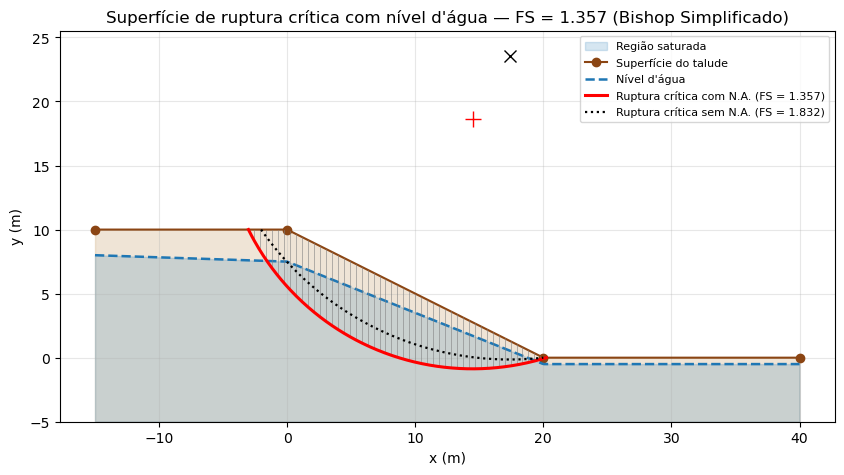

In [10]:
slices_crit = build_slices(xc_crit, yc_crit, R_crit, n_slices=50, com_agua=True)
x_entry, x_exit = slices_crit["x_entry"], slices_crit["x_exit"]

xs_plot = np.linspace(surf_x[0], surf_x[-1], 500)
xs_arc = np.linspace(x_entry, x_exit, 200)
ys_arc = circle_y(xs_arc, xc_crit, yc_crit, R_crit)
xs_arc_s = np.linspace(*find_entry_exit(xc_seco, yc_seco, R_seco), 200)  # arco critico do caso seco

y_base_plot = surf_y.min() - 5
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.fill_between(xs_plot, surface_y(xs_plot), y_base_plot, color="tan", alpha=0.35)
ax.fill_between(xs_plot, water_y(xs_plot), y_base_plot, color="tab:blue", alpha=0.18,
                label="Região saturada")
ax.plot(surf_x, surf_y, "o-", color="saddlebrown", label="Superfície do talude")
ax.plot(xs_plot, water_y(xs_plot), "--", color="tab:blue", lw=1.8, label="Nível d'água")

# fatias: parte saturada destacada
for xl in np.linspace(x_entry, x_exit, 51)[:-1]:
    ytop = surface_y(xl)
    ybot = circle_y(np.array([xl]), xc_crit, yc_crit, R_crit)[0]
    ax.plot([xl, xl], [ybot, ytop], color="gray", lw=0.4)

ax.plot(xs_arc, ys_arc, "r-", lw=2.2, label=f"Ruptura crítica com N.A. (FS = {fs_crit:.3f})")
ax.plot(xc_crit, yc_crit, "r+", ms=12)
ax.plot(xs_arc_s, circle_y(xs_arc_s, xc_seco, yc_seco, R_seco), "k:", lw=1.6,
        label=f"Ruptura crítica sem N.A. (FS = {fs_seco:.3f})")
ax.plot(xc_seco, yc_seco, "kx", ms=8)

ax.set_aspect("equal", adjustable="box")
ax.set_ylim(y_base_plot, max(yc_crit, yc_seco) + 2)
ax.set_title(f"Superfície de ruptura crítica com nível d'água — FS = {fs_crit:.3f} (Bishop Simplificado)")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.3)
plt.show()

### 8.2 Poropressão e peso das fatias ao longo da superfície crítica

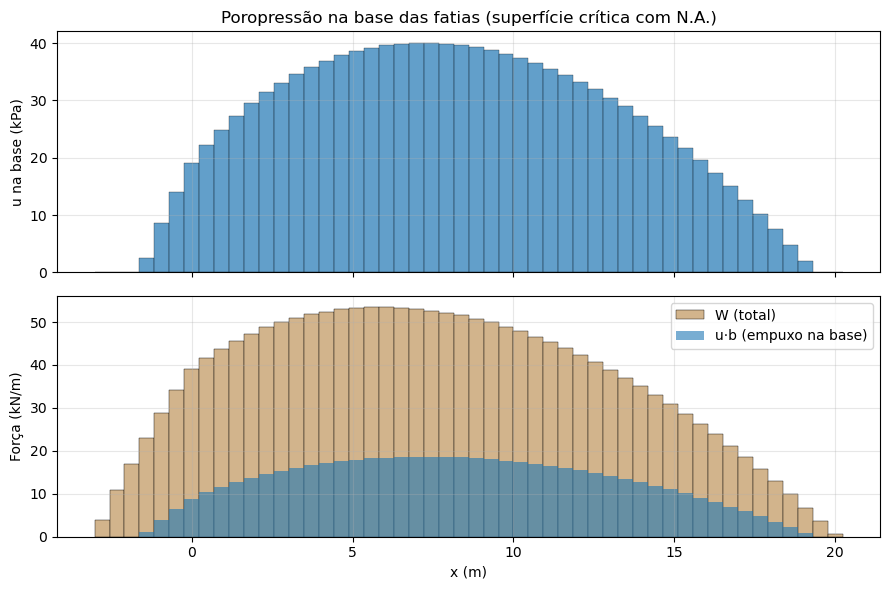

Poropressão máxima na base: 40.1 kPa
Fatias com base abaixo do N.A.: 45 de 50


In [11]:
s = slices_crit
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
ax1.bar(s["x_mid"], s["u"], width=s["b"], color="tab:blue", alpha=0.7, edgecolor="k", linewidth=0.3)
ax1.set_ylabel("u na base (kPa)")
ax1.set_title("Poropressão na base das fatias (superfície crítica com N.A.)")
ax1.grid(alpha=0.3)

ax2.bar(s["x_mid"], s["W"], width=s["b"], color="tan", edgecolor="k", linewidth=0.3, label="W (total)")
ax2.bar(s["x_mid"], s["u"] * s["b"], width=s["b"], color="tab:blue", alpha=0.6, label="u·b (empuxo na base)")
ax2.set_ylabel("Força (kN/m)")
ax2.set_xlabel("x (m)")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Poropressão máxima na base: {s['u'].max():.1f} kPa")
print(f"Fatias com base abaixo do N.A.: {np.sum(s['u'] > 0)} de {len(s['u'])}")

### 8.3 Mapa dos centros testados (menor FS por posição do centro) — com N.A.

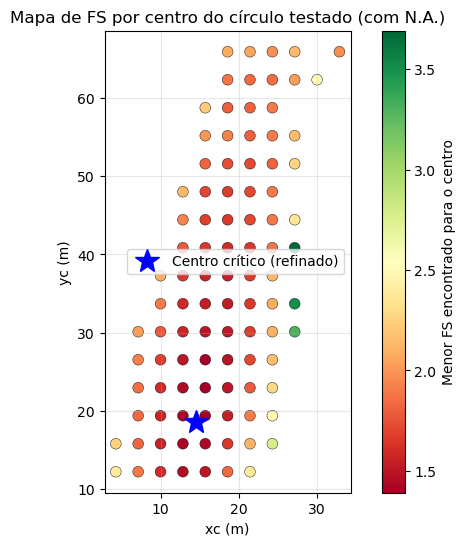

In [12]:
# Para cada combinação (xc, yc) testada, guarda o menor FS entre os raios avaliados
melhor_por_centro = {}
for xc, yc, R, fs in resultados_grid:
    key = (xc, yc)
    if key not in melhor_por_centro or fs < melhor_por_centro[key]:
        melhor_por_centro[key] = fs

xs_c = np.array([k[0] for k in melhor_por_centro])
ys_c = np.array([k[1] for k in melhor_por_centro])
fs_c = np.array([v for v in melhor_por_centro.values()])

plt.figure(figsize=(8, 6))
sc = plt.scatter(xs_c, ys_c, c=fs_c, cmap="RdYlGn", s=60, edgecolor="k", linewidth=0.3)
plt.colorbar(sc, label="Menor FS encontrado para o centro")
plt.plot(xc_crit, yc_crit, "b*", ms=18, label="Centro crítico (refinado)")
plt.title("Mapa de FS por centro do círculo testado (com N.A.)")
plt.xlabel("xc (m)")
plt.ylabel("yc (m)")
plt.legend()
plt.gca().set_aspect("equal", adjustable="box")
plt.grid(alpha=0.3)
plt.show()

## 9. Avaliar um círculo específico (opcional)

Calcula o FS de um círculo definido manualmente, com e sem nível d'água.

In [13]:
xc_manual = xc_crit
yc_manual = yc_crit
R_manual = R_crit

fs_man_agua = fs_for_circle(xc_manual, yc_manual, R_manual, n_slices=50, com_agua=True)
fs_man_seco = fs_for_circle(xc_manual, yc_manual, R_manual, n_slices=50, com_agua=False)
print(f"Círculo xc={xc_manual:.2f}, yc={yc_manual:.2f}, R={R_manual:.2f}")
print(f"  FS com N.A. = {fs_man_agua:.4f}")
print(f"  FS seco     = {fs_man_seco:.4f}")

Círculo xc=14.47, yc=18.64, R=19.51
  FS com N.A. = 1.3569
  FS seco     = 1.9048


## 10. Resumo dos resultados

In [14]:
print("="*55)
print("RESUMO DA ANALISE DE ESTABILIDADE DE TALUDE COM N.A.")
print("="*55)
print("Metodo: Bishop Simplificado (superficie circular, tensoes efetivas)")
print(f"Solo: gamma = {gamma} | gamma_sat = {gamma_sat} | gamma_w = {gamma_w} kN/m3")
print(f"      c' = {c} kPa | phi' = {phi_deg} graus")
print("-"*55)
print("Circulo critico COM nivel d'agua:")
print(f"  xc = {xc_crit:.3f} m | yc = {yc_crit:.3f} m | R = {R_crit:.3f} m")
print(f"  FS minimo = {fs_crit:.3f}")
print("Circulo critico SEM nivel d'agua (referencia):")
print(f"  xc = {xc_seco:.3f} m | yc = {yc_seco:.3f} m | R = {R_seco:.3f} m")
print(f"  FS minimo = {fs_seco:.3f}")
print(f"Reducao do FS pelo N.A.: {100*(fs_seco - fs_crit)/fs_seco:.1f} %")
print("-"*55)
if fs_crit < 1.0:
    print("=> Talude INSTAVEL (FS < 1.0)")
elif fs_crit < 1.5:
    print("=> Talude com FS abaixo do minimo usual de projeto (1.5)")
else:
    print("=> Talude considerado ESTAVEL (FS >= 1.5)")
print("="*55)

RESUMO DA ANALISE DE ESTABILIDADE DE TALUDE COM N.A.
Metodo: Bishop Simplificado (superficie circular, tensoes efetivas)
Solo: gamma = 18.0 | gamma_sat = 20.0 | gamma_w = 9.81 kN/m3
      c' = 10.0 kPa | phi' = 28.0 graus
-------------------------------------------------------
Circulo critico COM nivel d'agua:
  xc = 14.470 m | yc = 18.640 m | R = 19.510 m
  FS minimo = 1.357
Circulo critico SEM nivel d'agua (referencia):
  xc = 17.391 m | yc = 23.527 m | R = 23.671 m
  FS minimo = 1.832
Reducao do FS pelo N.A.: 26.0 %
-------------------------------------------------------
=> Talude com FS abaixo do minimo usual de projeto (1.5)
